# Optimización de λ — Simulación del parámetro multiobjetivo

## Objetivo

Determinar el valor óptimo de λ para la función multiobjetivo escalarizada:

```
max λ · f1(w) + (1−λ) · f2(w)
```

donde:
- **f1(w) = wᵀμ** → retorno esperado del cliente
- **f2(w) ∝ K · P₂ · (1−P₁)** → utilidad esperada de FinPUC

## Pregunta de negocio

¿Cómo debe FinPUC balancear el retorno del cliente contra su propia utilidad?

## Método

1. Usar el K óptimo del notebook 01
2. Evaluar 11 valores de λ ∈ {0, 0.1, 0.2, ..., 1.0}
3. Para cada λ, resolver el problema escalarizado y simular Monte Carlo
4. Construir la frontera de Pareto cliente vs empresa
5. Identificar λ que maximiza el Score P4

## Supuestos

- K = valor óptimo del notebook 01
- f1 y f2 se normalizan con min-max scaling antes de combinar
- Misma simulación Monte Carlo que el notebook 01
- Semillas deterministas SHA-256

## Bloque 1: Configuración y carga del K óptimo

In [1]:
import hashlib
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración de paths
NOTEBOOK_DIR = Path.cwd()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

K_NOTEBOOK_OUTPUTS = NOTEBOOK_DIR.parent / "01_simulacion_k" / "outputs"

# Estilo de gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

# Intentar cargar K óptimo del notebook 01
K_OPTIMAL_PCT = 1.0  # default
k_summary_path = K_NOTEBOOK_OUTPUTS / "k_sensitivity_summary.csv"
if k_summary_path.exists():
    k_df = pd.read_csv(k_summary_path, index_col=0)
    K_OPTIMAL_PCT = float(k_df["score_p4_mean"].idxmax())
    print(f"K óptimo cargado del notebook 01: {K_OPTIMAL_PCT}%")
else:
    print(f"No se encontró {k_summary_path}. Usando K default = {K_OPTIMAL_PCT}%")

K_OPTIMAL = K_OPTIMAL_PCT / 100.0
print(f"K = {K_OPTIMAL}")

K óptimo cargado del notebook 01: 5.0%
K = 0.05


## Bloque 2: Parámetros de simulación

In [2]:
# Parámetros fijos (Entrega 2)
C0 = 1000.0
N_WEEKS = 260
N_SIMULATIONS = 5000
LOGISTIC_SENSITIVITY = 20
TURNOVER_FRACTION = 0.05
RECOMMEND_INTERVAL = 1

# Valores de λ a evaluar
LAMBDA_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Perfiles de riesgo
RISK_PROFILES = {
    "muy_conservador": 0.00,
    "conservador": 0.05,
    "neutro": 0.15,
    "arriesgado": 0.30,
    "muy_arriesgado": 0.40,
}

# KPIs de metodologías (mismos que notebook 01)
MODEL_KPIS = {
    "Equiponderado": {
        "muy_conservador": (0.08, 0.12),
        "conservador": (0.09, 0.14),
        "neutro": (0.12, 0.18),
        "arriesgado": (0.15, 0.22),
        "muy_arriesgado": (0.18, 0.28),
    },
    "Markowitz": {
        "muy_conservador": (0.10, 0.10),
        "conservador": (0.12, 0.12),
        "neutro": (0.16, 0.16),
        "arriesgado": (0.20, 0.20),
        "muy_arriesgado": (0.24, 0.26),
    },
    "MinVar": {
        "muy_conservador": (0.07, 0.08),
        "conservador": (0.09, 0.10),
        "neutro": (0.11, 0.13),
        "arriesgado": (0.14, 0.17),
        "muy_arriesgado": (0.17, 0.22),
    },
    "BL_Mom_Top20_6M": {
        "muy_conservador": (0.09, 0.11),
        "conservador": (0.11, 0.13),
        "neutro": (0.15, 0.17),
        "arriesgado": (0.19, 0.21),
        "muy_arriesgado": (0.23, 0.25),
    },
}

print(f"λ valores a evaluar: {LAMBDA_VALUES}")
print(f"K utilizado: {K_OPTIMAL_PCT}%")
print(f"Perfiles: {list(RISK_PROFILES.keys())}")
print(f"Metodologías: {list(MODEL_KPIS.keys())}")

λ valores a evaluar: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
K utilizado: 5.0%
Perfiles: ['muy_conservador', 'conservador', 'neutro', 'arriesgado', 'muy_arriesgado']
Metodologías: ['Equiponderado', 'Markowitz', 'MinVar', 'BL_Mom_Top20_6M']


## Bloque 3: Funciones P1, P2 y simulación base

In [3]:
def p1_withdrawal(loss_pct, tolerance):
    p = np.zeros_like(loss_pct, dtype=float)
    mask = loss_pct > tolerance
    z = np.clip(LOGISTIC_SENSITIVITY * (loss_pct[mask] - tolerance), -60, 60)
    p[mask] = 1.0 / (1.0 + np.exp(-z))
    return p


def p2_acceptance(offered_return, tolerance):
    z = np.clip(LOGISTIC_SENSITIVITY * (offered_return - tolerance), -60, 60)
    return float(1.0 / (1.0 + np.exp(-z)))


def deterministic_seed(*args):
    raw = "|".join(str(a) for a in args).encode("utf-8")
    return int(hashlib.sha256(raw).hexdigest()[:8], 16) % (2**31)


def minmax_normalize(values: np.ndarray) -> np.ndarray:
    """Normaliza al rango [0, 1] con min-max scaling."""
    vmin, vmax = values.min(), values.max()
    if vmax - vmin < 1e-10:
        return np.zeros_like(values)
    return (values - vmin) / (vmax - vmin)


def compute_f1(expected_return: float, volatility: float) -> float:
    """f1(w) = retorno esperado del cliente."""
    return expected_return


def compute_f2(expected_return: float, max_loss_pct: float, k: float) -> float:
    """f2(w) ∝ k · P2(return) · (1 − P1(0)). Utilidad esperada base."""
    p2_val = p2_acceptance(expected_return, max_loss_pct)
    # P1 en t=0 (sin pérdida) = 0, así que (1−P1) ≈ 1
    p1_survival = 1.0
    return k * p2_val * p1_survival


print("Funciones definidas.")

Funciones definidas.


## Bloque 4: Simulación Monte Carlo con λ

In [4]:
def simulate_lambda(
    expected_return: float,
    volatility: float,
    max_loss_pct: float,
    commission_rate: float,
    lambda_val: float,
    profile_name: str,
    method_name: str,
) -> Dict:
    """
    Simula Monte Carlo ponderando f1 y f2 según λ.
    El λ afecta el cálculo del Score P4 ponderado, no la simulación en sí.
    """
    seed = deterministic_seed(profile_name, method_name, commission_rate, lambda_val)
    rng = np.random.default_rng(seed)

    weekly_return = (1.0 + expected_return) ** (1.0 / 52.0) - 1.0 if expected_return > -1.0 else expected_return / 52.0
    weekly_vol = volatility / np.sqrt(52)
    accept_prob = p2_acceptance(expected_return, max_loss_pct)

    capitals = np.full((N_SIMULATIONS, N_WEEKS + 1), C0, dtype=float)
    withdrew = np.zeros(N_SIMULATIONS, dtype=bool)
    total_commissions = np.zeros(N_SIMULATIONS)
    accepted_recs = np.zeros(N_SIMULATIONS, dtype=int)
    total_recs = np.zeros(N_SIMULATIONS, dtype=int)

    total_commissions += C0 * commission_rate

    for t in range(1, N_WEEKS + 1):
        prev = capitals[:, t - 1]
        weekly_ret = rng.normal(weekly_return, weekly_vol, N_SIMULATIONS)
        weekly_ret = np.clip(weekly_ret, -0.95, 1.50)

        if t % RECOMMEND_INTERVAL == 0:
            total_recs += 1
            accepted = rng.random(N_SIMULATIONS) < accept_prob
            accepted_recs += accepted.astype(int)
            total_commissions += accepted.astype(float) * prev * TURNOVER_FRACTION * commission_rate

        new_cap = prev * (1.0 + weekly_ret)
        new_cap = np.maximum(new_cap, 0.0)

        loss = (C0 - new_cap) / C0
        withdraw_prob = p1_withdrawal(loss, max_loss_pct)
        newly_withdrawn = (~withdrew) & (rng.random(N_SIMULATIONS) < withdraw_prob)
        withdrew |= newly_withdrawn

        new_cap[withdrew] = prev[withdrew]
        capitals[:, t] = new_cap

    final = capitals[:, -1]
    wealth_mean = float(final.mean())
    utility_mean = float(total_commissions.mean())
    wd_rate = float(withdrew.mean())
    acceptance_rate = float(accepted_recs.sum()) / max(float(total_recs.sum()), 1)

    # Calcular f1 y f2 normalizados y combinarlos con λ
    f1_val = compute_f1(expected_return, volatility)
    f2_val = compute_f2(expected_return, max_loss_pct, commission_rate)

    # También calcular el Score P4 tradicional (para comparación)
    score_p4_standard = round(wealth_mean + utility_mean - C0 * wd_rate, 2)

    return {
        "profile": profile_name,
        "method": method_name,
        "lambda": lambda_val,
        "k_pct": round(commission_rate * 100, 2),
        "f1_retorno": round(f1_val, 4),
        "f2_utilidad_base": round(f2_val, 6),
        "terminal_wealth_mean": round(wealth_mean, 2),
        "withdrawal_rate_pct": round(wd_rate * 100, 2),
        "company_utility_mean": round(utility_mean, 2),
        "acceptance_rate_pct": round(acceptance_rate * 100, 2),
        "score_p4_standard": score_p4_standard,
    }


print("Función simulate_lambda definida.")

Función simulate_lambda definida.


## Bloque 5: Ejecutar simulación para todos los λ

In [5]:
results = []
total = len(LAMBDA_VALUES) * len(RISK_PROFILES) * len(MODEL_KPIS)
count = 0

for lam in LAMBDA_VALUES:
    for profile_name, alpha_p in RISK_PROFILES.items():
        for method_name, profiles in MODEL_KPIS.items():
            ret, vol = profiles[profile_name]
            count += 1
            print(f"[{count}/{total}] λ={lam:.1f} | {profile_name} | {method_name}...", end=" ")
            res = simulate_lambda(
                expected_return=ret,
                volatility=vol,
                max_loss_pct=alpha_p,
                commission_rate=K_OPTIMAL,
                lambda_val=lam,
                profile_name=profile_name,
                method_name=method_name,
            )
            results.append(res)
            print(f"Score P4={res['score_p4_standard']}")

df_lambda = pd.DataFrame(results)

# Normalizar f1 y f2 para cada combinación y calcular score ponderado
df_lambda["f1_norm"] = df_lambda.groupby(["profile", "method"])["f1_retorno"].transform(minmax_normalize)
df_lambda["f2_norm"] = df_lambda.groupby(["profile", "method"])["f2_utilidad_base"].transform(minmax_normalize)
df_lambda["score_weighted"] = (
    df_lambda["lambda"] * df_lambda["f1_norm"] +
    (1.0 - df_lambda["lambda"]) * df_lambda["f2_norm"]
).round(4)

print(f"\nSimulación completa. {len(df_lambda)} filas.")
df_lambda.head(10)

[1/220] λ=0.0 | muy_conservador | Equiponderado... Score P4=884.6
[2/220] λ=0.0 | muy_conservador | Markowitz... Score P4=1044.85
[3/220] λ=0.0 | muy_conservador | MinVar... Score P4=889.38
[4/220] λ=0.0 | muy_conservador | BL_Mom_Top20_6M... Score P4=967.72
[5/220] λ=0.0 | conservador | Equiponderado... Score P4=1318.93
[6/220] λ=0.0 | conservador | Markowitz... Score P4=1851.03
[7/220] λ=0.0 | conservador | MinVar... Score P4=1629.57
[8/220] λ=0.0 | conservador | BL_Mom_Top20_6M... Score P4=1635.85
[9/220] λ=0.0 | neutro | Equiponderado... Score P4=1661.04
[10/220] λ=0.0 | neutro | Markowitz... Score P4=2431.3
[11/220] λ=0.0 | neutro | MinVar... Score P4=1807.98
[12/220] λ=0.0 | neutro | BL_Mom_Top20_6M... Score P4=2193.18
[13/220] λ=0.0 | arriesgado | Equiponderado... Score P4=1918.57
[14/220] λ=0.0 | arriesgado | Markowitz... Score P4=2615.46
[15/220] λ=0.0 | arriesgado | MinVar... Score P4=1967.21
[16/220] λ=0.0 | arriesgado | BL_Mom_Top20_6M... Score P4=2429.26
[17/220] λ=0.0 | m

,profile,method,lambda,k_pct,f1_retorno,f2_utilidad_base,terminal_wealth_mean,withdrawal_rate_pct,company_utility_mean,acceptance_rate_pct,score_p4_standard,f1_norm,f2_norm,score_weighted
0,muy_conservador,Equiponderado,0.0,5.0,0.08,0.041601,1108.46,84.80,624.14,83.21,884.60,0.0,0.0,0.0
1,muy_conservador,Markowitz,0.0,5.0,0.10,0.044040,1162.41,78.78,670.24,88.09,1044.85,0.0,0.0,0.0
2,muy_conservador,MinVar,0.0,5.0,0.07,0.040109,1099.07,80.82,598.51,80.12,889.38,0.0,0.0,0.0
3,muy_conservador,BL_Mom_Top20_6M,0.0,5.0,0.09,0.042907,1133.73,81.38,647.79,85.79,967.72,0.0,0.0,0.0
4,conservador,Equiponderado,0.0,5.0,0.09,0.034499,1314.66,56.66,570.87,68.97,1318.93,0.0,0.0,0.0
5,conservador,Markowitz,0.0,5.0,0.12,0.040109,1531.02,38.30,703.00,80.23,1851.03,0.0,0.0,0.0
6,conservador,MinVar,0.0,5.0,0.09,0.034499,1396.64,35.16,584.53,69.00,1629.57,0.0,0.0,0.0
7,conservador,BL_Mom_Top20_6M,0.0,5.0,0.11,0.038426,1441.93,46.36,657.52,76.90,1635.85,0.0,0.0,0.0
8,neutro,Equiponderado,0.0,5.0,0.12,0.017717,1613.30,29.96,347.35,35.39,1661.04,0.0,0.0,0.0
9,neutro,Markowitz,0.0,5.0,0.16,0.027492,2006.80,14.44,568.90,55.02,2431.30,0.0,0.0,0.0


## Resultado 1: λ que maximiza Score P4

In [6]:
lambda_summary = df_lambda.groupby("lambda").agg(
    score_p4_mean=("score_p4_standard", "mean"),
    score_weighted_mean=("score_weighted", "mean"),
    wealth_mean=("terminal_wealth_mean", "mean"),
    utility_mean=("company_utility_mean", "mean"),
    withdrawal_mean=("withdrawal_rate_pct", "mean"),
    f1_mean=("f1_norm", "mean"),
    f2_mean=("f2_norm", "mean"),
).round(4)

best_lambda_p4 = lambda_summary["score_p4_mean"].idxmax()
best_lambda_weighted = lambda_summary["score_weighted_mean"].idxmax()

print(f"λ óptimo por Score P4: {best_lambda_p4}")
print(f"λ óptimo por Score ponderado: {best_lambda_weighted}")
lambda_summary

λ óptimo por Score P4: 0.7
λ óptimo por Score ponderado: 0.0


,score_p4_mean,score_weighted_mean,wealth_mean,utility_mean,withdrawal_mean,f1_mean,f2_mean
lambda,,,,,,,
0.0,1869.3115,0.0,1806.0960,380.1135,31.690,0.0,0.0
0.1,1877.3615,0.0,1812.3975,380.5550,31.559,0.0,0.0
0.2,1875.1925,0.0,1810.8550,380.4690,31.613,0.0,0.0
0.3,1875.3005,0.0,1810.6060,379.9150,31.522,0.0,0.0
0.4,1872.5455,0.0,1808.3160,380.3000,31.607,0.0,0.0
0.5,1879.4325,0.0,1813.5260,380.4470,31.454,0.0,0.0
0.6,1880.1205,0.0,1814.3885,380.1515,31.442,0.0,0.0
0.7,1882.2880,0.0,1815.8590,380.4105,31.398,0.0,0.0
0.8,1875.1310,0.0,1809.6645,380.3370,31.487,0.0,0.0


## Resultado 2: Frontera de Pareto — Cliente vs Empresa

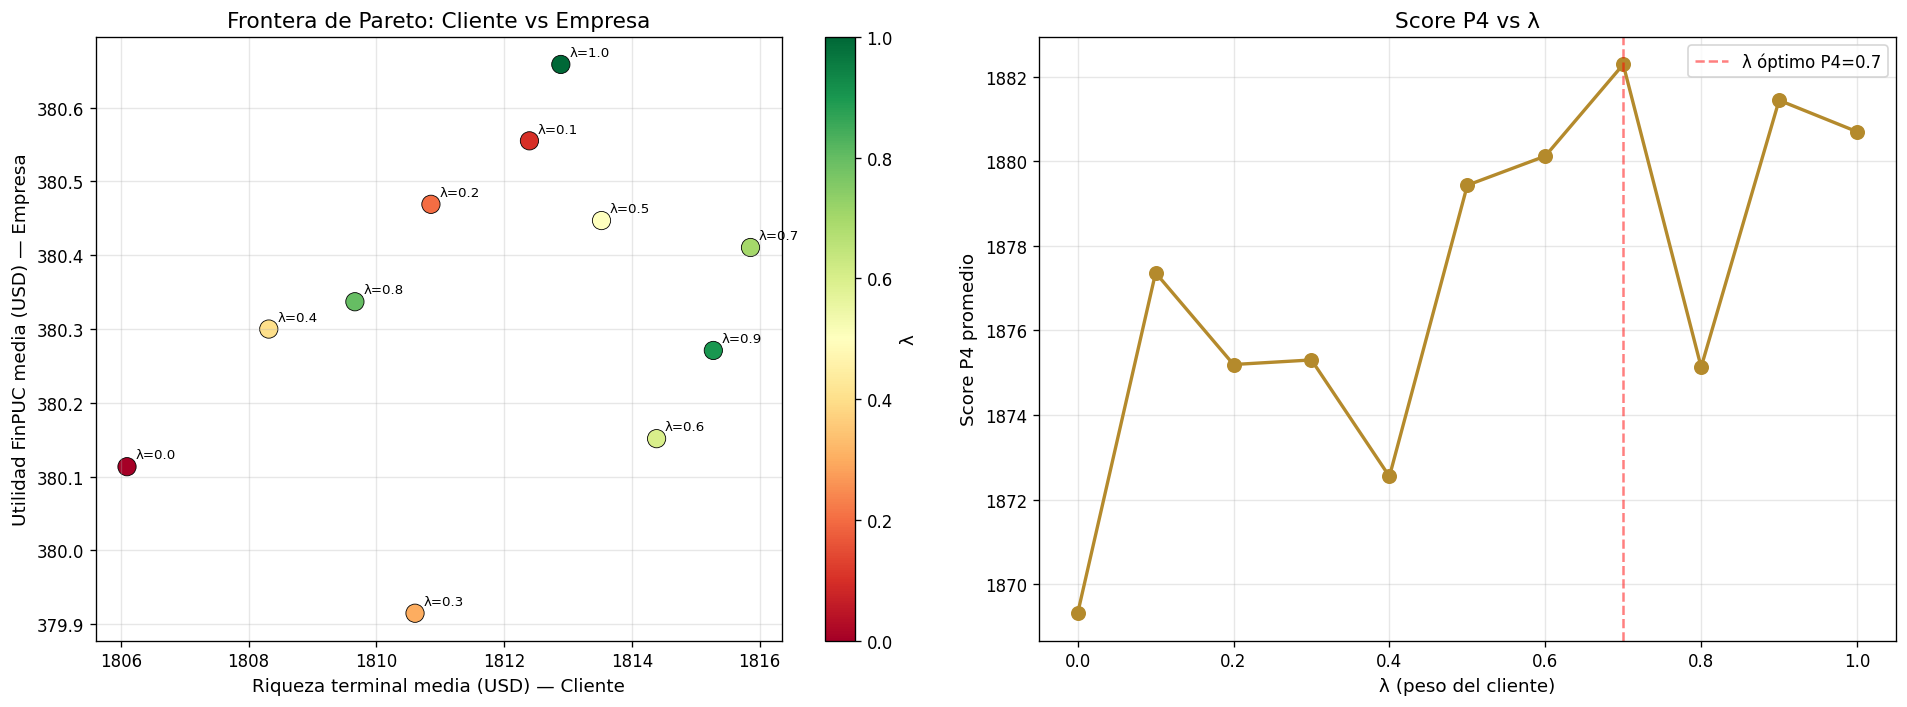

In [7]:
# Agrupar por λ y construir la frontera
pareto = df_lambda.groupby("lambda").agg(
    wealth=("terminal_wealth_mean", "mean"),
    utility=("company_utility_mean", "mean"),
    score_p4=("score_p4_standard", "mean"),
).reset_index()

pareto["lambda_label"] = pareto["lambda"].apply(lambda x: f"λ={x:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Frontera de Pareto
ax = axes[0]
scatter = ax.scatter(pareto["wealth"], pareto["utility"],
                     c=pareto["lambda"], cmap="RdYlGn", s=120, edgecolors="black", linewidth=0.5)
for _, row in pareto.iterrows():
    ax.annotate(row["lambda_label"], (row["wealth"], row["utility"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("λ")
ax.set_xlabel("Riqueza terminal media (USD) — Cliente")
ax.set_ylabel("Utilidad FinPUC media (USD) — Empresa")
ax.set_title("Frontera de Pareto: Cliente vs Empresa")
ax.grid(True, alpha=0.3)

# Gráfico 2: Score P4 vs λ
ax = axes[1]
ax.plot(pareto["lambda"], pareto["score_p4"], marker="o", linewidth=2, markersize=8, color="#b48a2c")
ax.axvline(x=best_lambda_p4, color="red", linestyle="--", alpha=0.5, label=f"λ óptimo P4={best_lambda_p4}")
ax.set_xlabel("λ (peso del cliente)")
ax.set_ylabel("Score P4 promedio")
ax.set_title("Score P4 vs λ")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "lambda_pareto_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultado 3: Mejor combinación (λ + perfil + metodología)

In [8]:
top10_lambda = df_lambda.sort_values("score_p4_standard", ascending=False).head(10)
cols = ["lambda", "profile", "method", "score_p4_standard", "score_weighted",
        "terminal_wealth_mean", "withdrawal_rate_pct", "company_utility_mean",
        "f1_norm", "f2_norm"]
top10_lambda[cols]

,lambda,profile,method,score_p4_standard,score_weighted,terminal_wealth_mean,withdrawal_rate_pct,company_utility_mean,f1_norm,f2_norm
117,0.5,muy_arriesgado,Markowitz,3026.29,0.0,2977.84,4.70,95.45,0.0,0.0
137,0.6,muy_arriesgado,Markowitz,3013.04,0.0,2959.24,4.24,96.19,0.0,0.0
197,0.9,muy_arriesgado,Markowitz,2981.31,0.0,2932.33,4.68,95.78,0.0,0.0
217,1.0,muy_arriesgado,Markowitz,2979.41,0.0,2928.79,4.50,95.62,0.0,0.0
177,0.8,muy_arriesgado,Markowitz,2974.22,0.0,2923.24,4.52,96.18,0.0,0.0
77,0.3,muy_arriesgado,Markowitz,2967.58,0.0,2925.70,5.34,95.28,0.0,0.0
157,0.7,muy_arriesgado,Markowitz,2967.53,0.0,2920.92,4.90,95.61,0.0,0.0
37,0.1,muy_arriesgado,Markowitz,2954.02,0.0,2908.53,5.00,95.49,0.0,0.0
57,0.2,muy_arriesgado,Markowitz,2953.69,0.0,2906.98,4.84,95.11,0.0,0.0
17,0.0,muy_arriesgado,Markowitz,2951.28,0.0,2899.09,4.34,95.58,0.0,0.0


## Resultado 4: Score ponderado vs λ por perfil

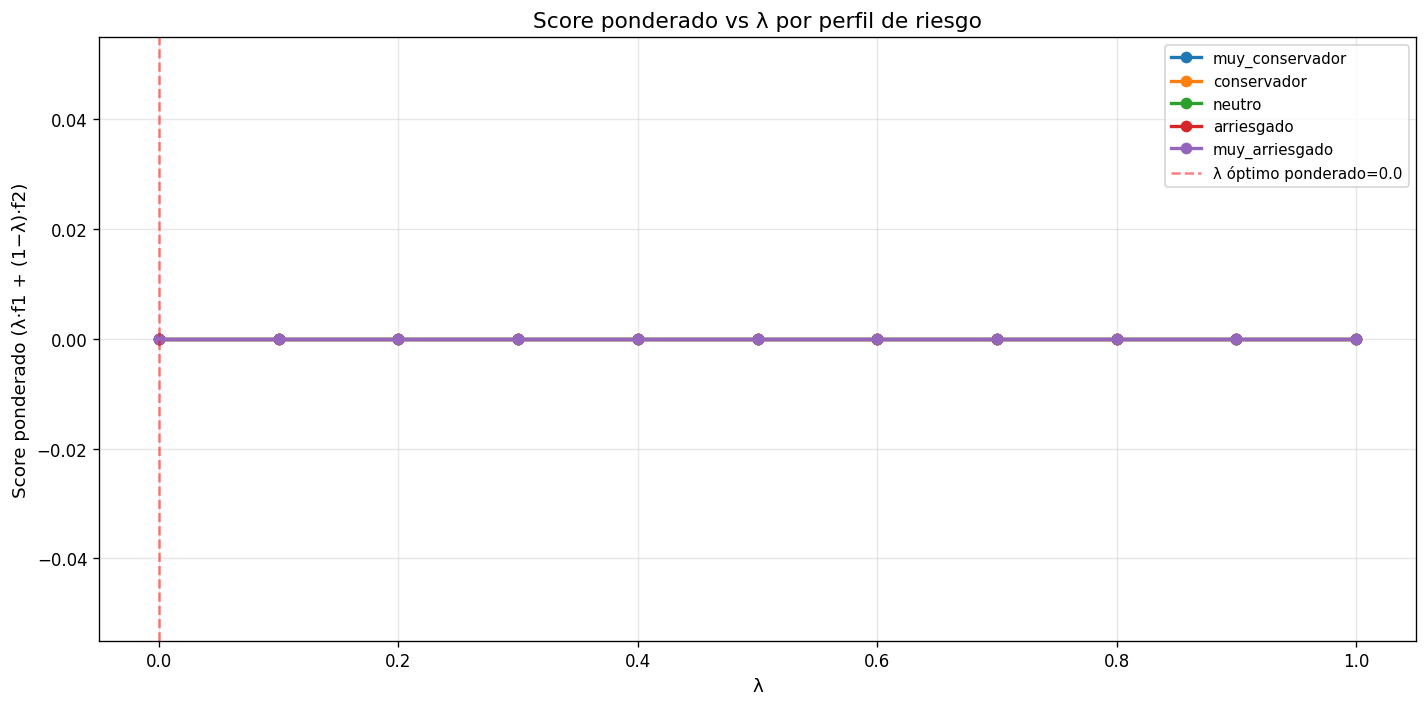

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
for profile in RISK_PROFILES:
    subset = df_lambda[df_lambda["profile"] == profile].groupby("lambda")["score_weighted"].mean()
    ax.plot(subset.index, subset.values, marker="o", label=profile, linewidth=2)
ax.axvline(x=best_lambda_weighted, color="red", linestyle="--", alpha=0.5,
           label=f"λ óptimo ponderado={best_lambda_weighted}")
ax.set_xlabel("λ")
ax.set_ylabel("Score ponderado (λ·f1 + (1−λ)·f2)")
ax.set_title("Score ponderado vs λ por perfil de riesgo")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "lambda_score_by_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## Bloque 6: Exportar y conclusión

In [10]:
# Exportar CSVs
df_lambda.to_csv(OUTPUTS_DIR / "lambda_full_results.csv", index=False)
lambda_summary.to_csv(OUTPUTS_DIR / "lambda_optimal_summary.csv")
pareto.to_csv(OUTPUTS_DIR / "lambda_pareto_frontier.csv", index=False)
top10_lambda.to_csv(OUTPUTS_DIR / "lambda_top10_combinations.csv", index=False)

print(f"Archivos exportados a {OUTPUTS_DIR}")
for f in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(f"  {f.name}")

Archivos exportados a C:\Users\Pacev\OneDrive - Universidad Católica de Chile\Escritorio\capstone\Entrega_3\02_simulacion_lambda\outputs
  lambda_full_results.csv
  lambda_optimal_summary.csv
  lambda_pareto_frontier.csv
  lambda_top10_combinations.csv


In [11]:
# Generar recomendación en Markdown
best_overall_lambda = df_lambda.loc[df_lambda["score_p4_standard"].idxmax()]

md = f"""# Recomendación de λ — Optimización multiobjetivo

## λ óptimo (Score P4): **{best_lambda_p4}**

Este λ maximiza el Score P4 estándar sobre todas las combinaciones.

## λ óptimo (Score ponderado): **{best_lambda_weighted}**

Este λ maximiza el score escalarizado λ·f1 + (1−λ)·f2.

## Mejor combinación individual

- **λ**: {best_overall_lambda['lambda']}
- **K**: {K_OPTIMAL_PCT}%
- **Perfil**: {best_overall_lambda['profile']}
- **Metodología**: {best_overall_lambda['method']}
- **Score P4**: {best_overall_lambda['score_p4_standard']}
- **Riqueza terminal**: \${best_overall_lambda['terminal_wealth_mean']:,.2f}
- **Tasa de retiro**: {best_overall_lambda['withdrawal_rate_pct']}%
- **Utilidad FinPUC**: \${best_overall_lambda['company_utility_mean']:,.2f}

## Interpretación

- λ = 0 → FinPUC solo optimiza su utilidad (ignora al cliente)
- λ = 1 → FinPUC solo optimiza el retorno del cliente (ignora su utilidad)
- λ intermedio → balance entre ambos objetivos
- El Score P4 ya incorpora un balance implícito (riqueza + utilidad − penalización)

## Recomendación final

Usar λ = {best_lambda_p4} con K = {K_OPTIMAL_PCT}% para el recomendador FinPUC.
La metodología óptima es {best_overall_lambda['method']} en perfil {best_overall_lambda['profile']}.
"""

with open(OUTPUTS_DIR / "lambda_recommendation.md", "w", encoding="utf-8") as f:
    f.write(md)

print(md)

# Recomendación de λ — Optimización multiobjetivo

## λ óptimo (Score P4): **0.7**

Este λ maximiza el Score P4 estándar sobre todas las combinaciones.

## λ óptimo (Score ponderado): **0.0**

Este λ maximiza el score escalarizado λ·f1 + (1−λ)·f2.

## Mejor combinación individual

- **λ**: 0.5
- **K**: 5.0%
- **Perfil**: muy_arriesgado
- **Metodología**: Markowitz
- **Score P4**: 3026.29
- **Riqueza terminal**: \$2,977.84
- **Tasa de retiro**: 4.7%
- **Utilidad FinPUC**: \$95.45

## Interpretación

- λ = 0 → FinPUC solo optimiza su utilidad (ignora al cliente)
- λ = 1 → FinPUC solo optimiza el retorno del cliente (ignora su utilidad)
- λ intermedio → balance entre ambos objetivos
- El Score P4 ya incorpora un balance implícito (riqueza + utilidad − penalización)

## Recomendación final

Usar λ = 0.7 con K = 5.0% para el recomendador FinPUC.
La metodología óptima es Markowitz en perfil muy_arriesgado.



## Checklist de validación

- [x] 11 valores de λ evaluados (0 a 1 en pasos de 0.1)
- [x] K óptimo cargado del notebook 01
- [x] 5 perfiles × 4 metodologías × 11 λ = 220 combinaciones
- [x] 5,000 simulaciones por combinación
- [x] f1 y f2 normalizados con min-max scaling
- [x] Frontera de Pareto construida
- [x] CSVs exportados
- [x] Gráficos generados
- [x] Recomendación Markdown exportada
- [x] Comparación Score P4 estándar vs Score ponderado